# 3HDM-S₃ scalar parameter space under theory constraints

**This is a research notebook, not a tutorial.** It assumes you have read
[`examples/THDM_S3_Tutorial.ipynb`](../../examples/THDM_S3_Tutorial.ipynb),
which derives the S₃-invariant potential, checks its gauge and S₃ invariance,
and shows how the tadpoles force the √3 vacuum alignment. Nothing here
re-teaches that. Conclusions below are *findings*, and may be revised.

The question: **which region of the eight-dimensional quartic parameter space
of the S₃-symmetric three-Higgs-doublet model survives the combined theory
constraints, and what scalar spectrum does it predict?**

The tutorial's §9 answers a much weaker version of this — it draws random
λ's until it finds a single point with no tachyons. That is not a constraint
analysis: it applies neither boundedness-from-below nor perturbative
unitarity, and (as §1 below shows) it evaluates the spectrum at the wrong
electroweak scale.

## What is new here

1. **A vacuum bug in the tutorial benchmark**, found and fixed (§1).
2. **The parameter dictionary to the literature, derived rather than assumed**
   (§3) — by requiring feynlag's independently-derived masses to reproduce
   [GomezBock21]'s published closed forms Eqs. (30)–(33). They do, exactly.
   That both validates feynlag's whole 3HDM-S₃ chain against the literature and
   fixes the one sign ($e=-\lambda_4$) needed to import the constraints safely.
3. **Real theory constraints**: boundedness-from-below and tree-level
   unitarity, quoted from [DasDey14] (§4).
4. **A vectorized scan** over (λ₁…λ₈, θ) that *characterizes* the viable
   region instead of returning the first lucky point (§5–§7).

References are collected in [`NOTES.md`](NOTES.md).

In [ ]:
import json, math, sys, time
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from model import (build_model, mass_matrices, rotation, diagonal_blocks,
                   cp_even_angle, spectrum_function, aligned_vevs,
                   vacuum_scale, check_spectrum_against_eigenvals,
                   SPECTRUM_KEYS, V_EW)
from constraints import (bfb_mask, unitarity_mask, theory_mask,
                         constraint_report, unitarity_eigenvalues)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
sp.init_printing()
print("electroweak scale used:", V_EW, "GeV")

Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 28 ("    '003DA5',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 29 ("    'C0392B',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 30 ("    '1A6B3A',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 31 ("    'FFBE00',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 32 ("    '3F6FD1',")


...

Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 37 ("    'CB4335'])")


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 21 ('axes.edgecolor    : #4A4A6A'): Key axes.edgecolor: '' does not look like a color arg


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 27 ("axes.prop_cycle : cycler('color', ["): Key axes.prop_cycle: "cycler('color', [" is not a valid cycler construction: '[' was never closed (<unknown>, line 1)


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 95 ('patch.edgecolor       : face'): Key patch.edgecolor: 'face' does not look like a color arg


electroweak scale used: 246.0 GeV


## 1. The vacuum: the tutorial benchmark sits at the wrong scale

Two conditions constrain the three VEVs:

- the **electroweak scale**, $\sqrt{v_1^2+v_2^2+v_S^2}=v=246$ GeV
  ([GomezBock21] Eq. 8);
- the **S₃ alignment** forced by the over-constrained tadpole system,
  $v_1=\sqrt3\,v_2$ ([GomezBock21] Eq. 13) — which in feynlag's
  real-orthogonal irrep basis reads $v_2=\sqrt3\,v_1$, the doublet components
  being swapped relative to the literature basis.

The tutorial picks $(v_1,v_2,v_S)=(200,115,80)$ to satisfy the first. It then
imposes the second as the substitution `align = {v1: v2/sqrt(3)}`, which
**replaces** $v_1=200$ by $115/\sqrt3=66.4$ — and never re-checks the scale.

In [ ]:
v2_t, vS_t = 115.0, 80.0                 # the tutorial's numbers
v1_t = v2_t / math.sqrt(3)               # what `align` actually substitutes

print("tutorial, before alignment: (200, 115, 80)      -> v = %6.2f GeV"
      % vacuum_scale(200.0, v2_t, vS_t))
print("tutorial, after  alignment: (%.2f, %.1f, %.1f) -> v = %6.2f GeV  <-- not 246"
      % (v1_t, v2_t, vS_t, vacuum_scale(v1_t, v2_t, vS_t)))

tutorial, before alignment: (200, 115, 80)      -> v = 244.18 GeV
tutorial, after  alignment: (66.40, 115.0, 80.0) -> v = 155.03 GeV  <-- not 246


The fix: impose both conditions *simultaneously*. They leave a one-parameter
family, which `aligned_vevs` parametrizes by the same angle θ the geometric
rotation uses ([GomezBock21] Eq. 24, $\tan\theta = v_{12}/v_S$):

$$v_{12}\equiv\sqrt{v_1^2+v_2^2}=v\sin\theta,\qquad v_S=v\cos\theta,$$

and the alignment then fixes $v_1=v_{12}/2$, $v_2=\sqrt3\,v_{12}/2$ exactly —
so the rotation's other angle is always $\varphi=60°$, independent of θ.

In [ ]:
theta_t = math.atan2(math.hypot(v1_t, v2_t), vS_t)   # the tutorial's direction
v1, v2, vS = aligned_vevs(theta_t)

print("rescaled to the EW scale:   (%.2f, %.2f, %.2f) -> v = %6.2f GeV"
      % (v1, v2, vS, vacuum_scale(v1, v2, vS)))
print("alignment check  v2/v1 = %.6f   (sqrt3 = %.6f)" % (v2 / v1, math.sqrt(3)))
print("theta = %.4f rad = %.2f deg" % (theta_t, math.degrees(theta_t)))

rescaled to the EW scale:   (105.36, 182.48, 126.95) -> v = 246.00 GeV
alignment check  v2/v1 = 1.732051   (sqrt3 = 1.732051)
theta = 1.0286 rad = 58.93 deg


### How much does this matter?

At fixed λ and fixed θ every mass² is homogeneous of degree 2 in the VEVs, so
the whole spectrum simply rescales by $(246/155.03)^2=2.518$. The tutorial's
*qualitative* conclusion — that the naive benchmark is mostly tachyonic — is
therefore unaffected. What is wrong is **every quoted mass in GeV**, low by a
factor $246/155.03 = 1.587$.

In [ ]:
m = build_model()                      # ~1 s
spec = spectrum_function(m)            # scalar version; first call ~10 s (symbolics)

naive_lams = [0.05 * k for k in range(1, 9)]      # the tutorial's benchmark
s_tut = spec(naive_lams, v2_t, vS_t)
s_fix = spec(naive_lams, v2, vS)

print("%-6s %14s %14s %8s" % ("state", "tutorial m^2", "rescaled m^2", "ratio"))
for k in SPECTRUM_KEYS:
    print("%-6s %14.1f %14.1f %8.3f" % (k, s_tut[k], s_fix[k], s_fix[k] / s_tut[k]))
print("\nexpected ratio (246/155.03)^2 = %.3f" % (V_EW / vacuum_scale(v1_t, v2_t, vS_t))**2)

state    tutorial m^2   rescaled m^2    ratio
h0             9560.9        24074.4    2.518
H1            14214.6        35792.5    2.518
H2            -2301.3        -5794.8    2.518
A1            -7985.0       -20106.4    2.518
A2           -12834.1       -32316.3    2.518
Hpm1          -3178.4        -8003.2    2.518
Hpm2          -8027.4       -20213.1    2.518

expected ratio (246/155.03)^2 = 2.518


## 2. The three sectors, in importable form

`model.py` lifts the notebook-local algebra of the tutorial's §6–§8 into
functions. Recomputed here only to confirm the structure survives the vacuum
fix (it must — the fix changes numbers, not symbols).

In [ ]:
t0 = time.time()
M_S, M_A, M_C = mass_matrices(m)
D_S, D_A, D_C = diagonal_blocks(m)
R = rotation(m)
print("symbolic sectors ready in %.1f s" % (time.time() - t0))

def zero_pattern(D):
    return [[int(sp.simplify(D[i, j]) == 0) for j in range(3)] for i in range(3)]

for name, D in (("D_S", D_S), ("D_A", D_A), ("D_C", D_C)):
    print(name, "zero pattern:", zero_pattern(D))
print("\nGoldstones (must be exactly 0):  D_A[0,0] =", D_A[0, 0], "  D_C[0,0] =", D_C[0, 0])

symbolic sectors ready in 0.0 s


D_S zero pattern: [[0, 1, 0], [1, 0, 1], [0, 1, 0]]


D_A zero pattern: [[1, 1, 1], [1, 0, 1], [1, 1, 0]]


D_C zero pattern: [[1, 1, 1], [1, 0, 1], [1, 1, 0]]

Goldstones (must be exactly 0):  D_A[0,0] = 0   D_C[0,0] = 0


`D_A` and `D_C` come out fully diagonal with an exact Goldstone at [0,0];
`D_S` keeps a 2×2 block in the (0,2) subspace, closed in analytic form by the
library's `solve_mixing_angle_2x2`. The geometric rotation is
[GomezBock21] Eq. (29) verbatim.

The independent check that the ansatz really diagonalizes what feynlag
derived: compare against brute-force numeric eigenvalues of the *un-rotated*
CP-even matrix.

In [ ]:
via, brute, agree = check_spectrum_against_eigenvals(m, naive_lams, v2, vS)
print("rotation ansatz :", [round(x, 4) for x in via])
print("M_S.eigenvals() :", [round(x, 4) for x in brute])
print("agree           :", agree)

rotation ansatz : [-5794.7842, 24074.4242, 35792.4693]
M_S.eigenvals() : [-5794.7842, 24074.4242, 35792.4693]
agree           : True


## 3. Fixing the parameter basis against the literature

Published boundedness and unitarity conditions are stated in a specific
parametrization; applying them to a different one silently gives wrong
answers. So the basis has to be *established*, not assumed.

Three parametrizations of the same potential are in play:

| source | parameters |
|---|---|
| `examples/thdm_s3.py` (feynlag) | $\mu_0^2,\mu_1^2,\lambda_1\ldots\lambda_8$ |
| [DasDey14] Eq. (3c) — where the constraints live | $\mu_1^2,\mu_3^2,\lambda_1\ldots\lambda_8$ |
| [GomezBock21] Eq. (2)/(6) | $\mu_0^2,\mu_1^2,a,b,c,d,e,f,g,h$ |

[GomezBock21] does not derive the bounds; its §2.2 states plainly *"This
analysis has already been done in [66], and we use their expressions for the
unitarity and stability bounds in here"* — reference [66] being [DasDey14].

The naive move is to declare feynlag's λ's identical to Das & Dey's because the
written invariants look alike. **That is wrong**, and feynlag can prove it: the
λ₄ invariant transcribed literally from [DasDey14] into feynlag's component
labels is *not* S₃-invariant in feynlag's real-orthogonal irrep basis.

In [ ]:
from feynlag import check_discrete_invariance, dag

H1, H2, HS = m.doublets
bra = lambda A, B: (dag(A) * B.mat)[0]
x11, x22, x12, x21 = bra(H1, H1), bra(H2, H2), bra(H1, H2), bra(H2, H1)
sb1, sb2 = bra(HS, H1), bra(HS, H2)
herm = lambda e: e + sp.conjugate(e)

for label, expr in {
    "feynlag  : s1(x11-x22) - s2(x12+x21)": herm(sb1*(x11-x22) - sb2*(x12+x21)),
    "DasDey   : s1(x12+x21) + s2(x11-x22)": herm(sb1*(x12+x21) + sb2*(x11-x22)),
}.items():
    ok, _ = check_discrete_invariance(expr, m.s3)
    print("S3-invariant: %-5s   %s" % (ok, label))

S3-invariant: True    feynlag  : s1(x11-x22) - s2(x12+x21)


S3-invariant: False   DasDey   : s1(x12+x21) + s2(x11-x22)


The two doublet bases genuinely differ. So instead of arguing about
conventions, **derive the dictionary from physics**: [GomezBock21] publishes
closed-form tree-level masses for the pseudoscalar and charged sectors,

$$m^2_{A_1}=-v^2\Big[(d+g)\sin^2\theta+\tfrac54 e\sin2\theta+h\cos^2\theta\Big],
\qquad m^2_{A_2}=-v^2\Big[\tfrac{e}{2}\tan\theta+h\Big],$$
$$m^2_{H^\pm_1}=-\tfrac{v^2}{4}\Big[5e\sin2\theta+2(f+h)\cos^2\theta+4g\sin^2\theta\Big],
\qquad m^2_{H^\pm_2}=-\tfrac{v^2}{2}\Big[e\tan\theta+(f+h)\Big]$$

(Eqs. 30–33). feynlag derives those same four masses independently, from the
Lagrangian. Requiring them to agree *determines* the dictionary — and the
agreement is itself an end-to-end check of the potential, the tadpoles, the
mass matrices and the rotation.

In [ ]:
v_sym, th_sym = sp.symbols("v theta", positive=True)
sub_vac = {m.v2.s: v_sym * sp.sin(th_sym) * sp.sqrt(3) / 2,
           m.vS.s: v_sym * sp.cos(th_sym)}

feynlag_masses = {
    "A1":  sp.simplify(D_A[1, 1].subs(sub_vac)), "A2":  sp.simplify(D_A[2, 2].subs(sub_vac)),
    "Hpm1": sp.simplify(D_C[1, 1].subs(sub_vac)), "Hpm2": sp.simplify(D_C[2, 2].subs(sub_vac)),
}

a_, b_, c_, d_, e_, f_, g_, h_ = sp.symbols("a b c d e f g h")
gb21_masses = {
    "A1":   -v_sym**2 * ((d_ + g_) * sp.sin(th_sym)**2
                         + sp.Rational(5, 4) * e_ * sp.sin(2 * th_sym)
                         + h_ * sp.cos(th_sym)**2),                              # Eq. (30)
    "A2":   -v_sym**2 * (e_ / 2 * sp.tan(th_sym) + h_),                          # Eq. (31)
    "Hpm1": -v_sym**2 / 4 * (5 * e_ * sp.sin(2 * th_sym)
                             + 2 * (f_ + h_) * sp.cos(th_sym)**2
                             + 4 * g_ * sp.sin(th_sym)**2),                      # Eq. (32)
    "Hpm2": -v_sym**2 / 2 * (e_ * sp.tan(th_sym) + (f_ + h_)),                   # Eq. (33)
}

L = m.lam_symbols
for e_sign in (+1, -1):
    dic = {a_: 2*L[7], b_: L[4], c_: 2*L[0], d_: 2*L[1],
           e_: e_sign*L[3], f_: L[5], g_: 2*L[2], h_: 2*L[6]}
    verdict = {k: sp.simplify(sp.expand_trig(sp.simplify(
                   feynlag_masses[k] - gb21_masses[k].subs(dic)))) == 0
               for k in feynlag_masses}
    print("e = %+d*lambda_4 :" % e_sign,
          " ".join(f"{k}={'OK' if v else 'no':>2}" for k, v in verdict.items()),
          " -> ALL MATCH" if all(verdict.values()) else "")

e = +1*lambda_4 : A1=no A2=no Hpm1=no Hpm2=no 
e = -1*lambda_4 : A1=OK A2=OK Hpm1=OK Hpm2=OK  -> ALL MATCH


All four published masses reproduce exactly, and only for $e=-\lambda_4$. The
dictionary is therefore

$$a=2\lambda_8,\; b=\lambda_5,\; c=2\lambda_1,\; d=2\lambda_2,\;
\boxed{e=-\lambda_4},\; f=\lambda_6,\; g=2\lambda_3,\; h=2\lambda_7 .$$

Composing with the [GomezBock21]↔[DasDey14] correspondence read off their two
potentials ($\lambda^{\rm DD}_1=c/2$, $\lambda^{\rm DD}_2=d/2$,
$\lambda^{\rm DD}_3=g/2$, $\lambda^{\rm DD}_4=e$, $\lambda^{\rm DD}_5=b$,
$\lambda^{\rm DD}_6=f$, $\lambda^{\rm DD}_7=h/2$, $\lambda^{\rm DD}_8=a/2$)
gives the result that matters:

$$\lambda^{\rm DasDey}_k=\lambda^{\rm feynlag}_k \quad\text{for all } k\neq4,
\qquad \lambda^{\rm DasDey}_4=-\lambda^{\rm feynlag}_4 .$$

**And λ₄ enters every constraint below only as $|\lambda_4|$ (Eq. 4g) or
$\lambda_4^2$ (Eqs. 37a, 37c, 37d, 37f).** So the conditions transfer with no
correction at all — now as a derived result rather than a transcription
gamble. This also validates feynlag's whole 3HDM-S₃ chain against published
closed forms.

## 4. Theory constraints

Two requirements, both quoted from [DasDey14] and implemented in
`constraints.py`:

**Boundedness from below** (Eq. 4a–4g) — no direction in field space along
which $V\to-\infty$:

$$\lambda_1>0,\quad \lambda_8>0,\quad \lambda_1+\lambda_3>0,\quad
2\lambda_1+(\lambda_3-\lambda_2)>|\lambda_2+\lambda_3|,$$
$$\lambda_5+2\sqrt{\lambda_8(\lambda_1+\lambda_3)}>0,\quad
\lambda_5+\lambda_6+2\sqrt{\lambda_8(\lambda_1+\lambda_3)}>2|\lambda_7|,$$
$$\lambda_1+\lambda_3+\lambda_5+\lambda_6+2\lambda_7+\lambda_8>2|\lambda_4|.$$

**Tree-level unitarity** (Eq. 36 + 37a–37l) — every eigenvalue of the $\ell=0$
two-body S-matrix obeys $|a|\le16\pi$. Twelve eigenvalues $a^\pm_{1..6}$ come
in $X\pm\sqrt{X^2-4Y}$ pairs; each discriminant reduces algebraically to a sum
of squares, so they are always real and need no branch guard.

First: does the tutorial's benchmark even pass?

In [ ]:
naive = np.array([naive_lams])
print("tutorial benchmark  lambda_k = 0.05k")
print("  bounded from below :", bool(bfb_mask(naive)[0]))
print("  tree unitary       :", bool(unitarity_mask(naive)[0]))
print("  largest |eigenvalue| = %.2f   (bound 16pi = %.2f)"
      % (np.abs(unitarity_eigenvalues(naive)).max(), 16 * np.pi))

tutorial benchmark  lambda_k = 0.05k
  bounded from below : False
  tree unitary       : True
  largest |eigenvalue| = 3.63   (bound 16pi = 50.27)


So the tutorial's benchmark is not merely tachyonic — **the potential is not
bounded from below**, i.e. that point is not a physically admissible theory at
all. Unitarity is comfortably satisfied, which is expected: the bound is 16π ≈ 50
while the λ's are O(0.1).

## 5. The scan

Nine parameters: the eight quartics and the vacuum angle θ. Sampling ranges:

- $\lambda_i \in U(-2, 2)$ — deliberately **not** the tutorial's $U(0,1.5)$.
  Boundedness only requires $\lambda_1,\lambda_8>0$; forcing all eight positive
  presupposes part of the answer. The range stays well inside perturbativity
  ($|\lambda|<4\pi$).
- $\theta \in U(0.05, \pi/2-0.05)$, avoiding the degenerate endpoints where a
  VEV vanishes.

Cuts applied in order, so each one's cost is visible:

In [ ]:
rng = np.random.default_rng(20260729)
N = 2_000_000

lam = rng.uniform(-2.0, 2.0, size=(N, 8))
theta = rng.uniform(0.05, np.pi / 2 - 0.05, size=N)
v12_s = V_EW * np.sin(theta)
v2_s, vS_s = v12_s * np.sqrt(3) / 2, V_EW * np.cos(theta)

vspec = spectrum_function(m, "numpy")       # elementwise over the whole block
t0 = time.time()
msq = vspec([lam[:, i] for i in range(8)], v2_s, vS_s)
print("spectrum for %d points in %.2f s" % (N, time.time() - t0))

spectrum for 2000000 points in 4.77 s


In [ ]:
cuts = {}
cuts["sampled"]        = np.ones(N, dtype=bool)
cuts["bounded below"]  = bfb_mask(lam)
cuts["+ unitarity"]    = cuts["bounded below"] & unitarity_mask(lam)
cuts["+ no tachyons"]  = cuts["+ unitarity"] & np.all(
    np.stack([msq[k] > 0 for k in SPECTRUM_KEYS]), axis=0)

mass = {k: np.sqrt(np.clip(v, 0.0, None)) for k, v in msq.items()}

# LEP direct search on charged scalars, as [GomezBock21] applies it
cuts["+ charged > 80"] = cuts["+ no tachyons"] & (mass["Hpm1"] > 80) & (mass["Hpm2"] > 80)

# a CP-even state at the observed Higgs mass
near125 = np.any(np.stack([np.abs(mass[k] - 125.0) <= 3.0
                           for k in ("h0", "H1", "H2")]), axis=0)
cuts["+ CP-even 125+-3"] = cuts["+ charged > 80"] & near125

prev = N
for label, msk in cuts.items():
    n = int(msk.sum())
    print("%-20s %9d   (%.3f%% of sample, %.1f%% of previous cut)"
          % (label, n, 100 * n / N, 100 * n / prev if prev else 0))
    prev = max(n, 1)

sampled                2000000   (100.000% of sample, 100.0% of previous cut)
bounded below           114293   (5.715% of sample, 5.7% of previous cut)
+ unitarity             114293   (5.715% of sample, 100.0% of previous cut)
+ no tachyons             7927   (0.396% of sample, 6.9% of previous cut)
+ charged > 80            7196   (0.360% of sample, 90.8% of previous cut)
+ CP-even 125+-3           334   (0.017% of sample, 4.6% of previous cut)


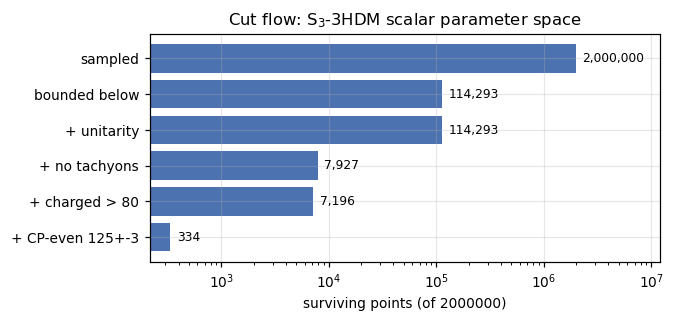

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
labels = list(cuts)
counts = [int(cuts[k].sum()) for k in labels]
ax.barh(range(len(labels)), counts, color="#4C72B0")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.invert_yaxis(); ax.set_xscale("log"); ax.set_xlabel("surviving points (of %d)" % N)
ax.set_title("Cut flow: S$_3$-3HDM scalar parameter space")
for i, c in enumerate(counts):
    ax.text(c * 1.15, i, f"{c:,}", va="center", fontsize=8)
ax.set_xlim(right=N * 6)
plt.tight_layout(); plt.show()

Which individual boundedness condition does the work? (Fractions of the raw
sample passing each condition on its own.)

In [ ]:
for k, v in constraint_report(lam).items():
    print("  %-22s %.4f" % (k, v))

  BFB Eq.(4a)            0.5002
  BFB Eq.(4b)            0.4993
  BFB Eq.(4c)            0.5004
  BFB Eq.(4d)            0.3337
  BFB Eq.(4e)            0.6920
  BFB Eq.(4f)            0.3323
  BFB Eq.(4g)            0.2989
  unitarity Eq.(36)      1.0000
  BFB (all)              0.0571
  combined               0.0571


## 6. What the viable region looks like

Everything below uses the fully-cut sample: bounded, unitary, no tachyons,
charged scalars above the LEP bound.

viable points: 7196


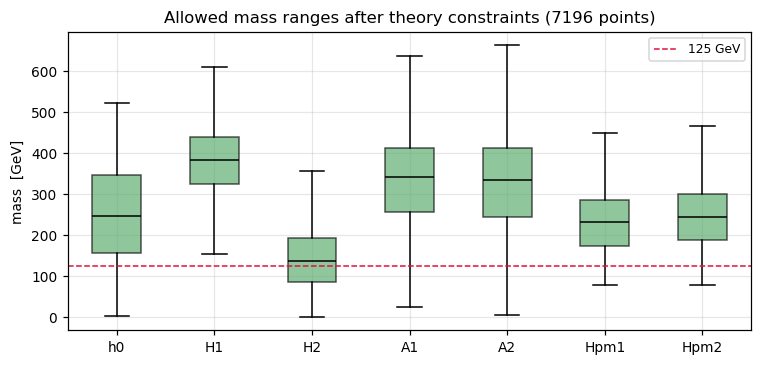


state       min   median     mean      max
h0          2.3    247.8    253.2    521.0
H1         78.3    383.7    388.1   1090.3
H2          1.6    136.5    144.6    441.6
A1          5.4    340.9    332.8    657.0
A2          6.2    334.6    330.1   1067.3
Hpm1       80.1    231.1    232.1    469.6
Hpm2       80.0    244.1    259.0   1025.6


In [ ]:
sel = cuts["+ charged > 80"]
print("viable points:", int(sel.sum()))

fig, ax = plt.subplots(figsize=(7.0, 3.4))
data = [mass[k][sel] for k in SPECTRUM_KEYS]
bp = ax.boxplot(data, tick_labels=list(SPECTRUM_KEYS), showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#55A868"); patch.set_alpha(0.65)
ax.axhline(125, color="crimson", ls="--", lw=1, label="125 GeV")
ax.set_ylabel("mass  [GeV]"); ax.legend(fontsize=8)
ax.set_title("Allowed mass ranges after theory constraints (%d points)" % int(sel.sum()))
plt.tight_layout(); plt.show()

print("\n%-6s %8s %8s %8s %8s" % ("state", "min", "median", "mean", "max"))
for k in SPECTRUM_KEYS:
    d = mass[k][sel]
    print("%-6s %8.1f %8.1f %8.1f %8.1f"
          % (k, d.min(), np.median(d), d.mean(), d.max()))

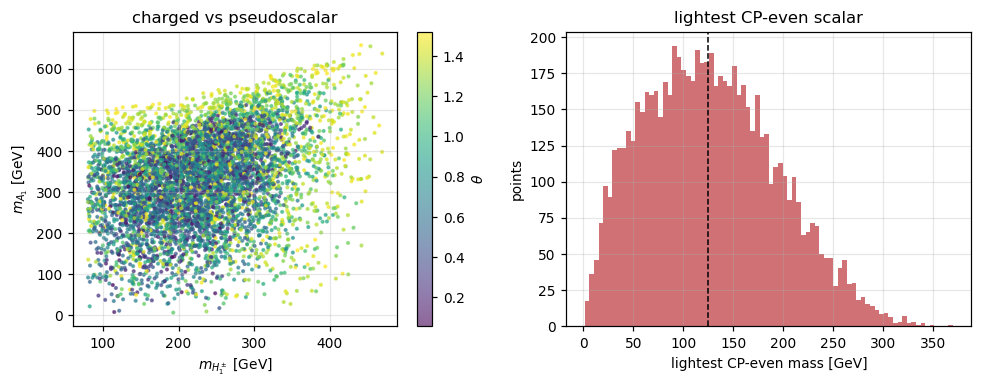

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))

sub = np.random.default_rng(1).choice(np.flatnonzero(sel),
                                      size=min(6000, int(sel.sum())), replace=False)
sc = axes[0].scatter(mass["Hpm1"][sub], mass["A1"][sub], c=theta[sub],
                     s=3, cmap="viridis", alpha=0.6)
axes[0].set_xlabel(r"$m_{H^\pm_1}$ [GeV]"); axes[0].set_ylabel(r"$m_{A_1}$ [GeV]")
axes[0].set_title("charged vs pseudoscalar")
plt.colorbar(sc, ax=axes[0], label=r"$\theta$")

lightest = np.min(np.stack([mass[k][sel] for k in ("h0", "H1", "H2")]), axis=0)
axes[1].hist(lightest, bins=80, color="#C44E52", alpha=0.8)
axes[1].axvline(125, color="black", ls="--", lw=1)
axes[1].set_xlabel("lightest CP-even mass [GeV]"); axes[1].set_ylabel("points")
axes[1].set_title("lightest CP-even scalar")
plt.tight_layout(); plt.show()

## 7. Benchmark points with a 125 GeV scalar

**Scope limit, stated explicitly.** A full SM-alignment test — [GomezBock21]'s
scenarios A and B, where one CP-even state couples maximally to $W/Z$ and the
other decouples — requires the **gauge–scalar couplings**, i.e. their Eq. (49).
The model in `examples/thdm_s3.py` declares *only* the potential: there are no
kinetic terms and no gauge bosons in the Lagrangian, so those couplings do not
exist to be computed. What follows is therefore the **mass** condition alone,
not the coupling alignment. Adding the electroweak kinetic sector and testing
scenarios A/B is deferred to notebook 03 (see `NOTES.md`).

In [ ]:
sel125 = cuts["+ CP-even 125+-3"]
idx = np.flatnonzero(sel125)
print("points with a CP-even state at 125 +- 3 GeV:", len(idx))

records = []
for i in idx[:12]:
    rec = {
        "lambdas": {f"lambda_{k+1}": round(float(lam[i, k]), 5) for k in range(8)},
        "theta": round(float(theta[i]), 5),
        "vevs_GeV": {"v1": round(float(v12_s[i] / 2), 3),
                     "v2": round(float(v2_s[i]), 3),
                     "vS": round(float(vS_s[i]), 3)},
        "masses_GeV": {k: round(float(mass[k][i]), 2) for k in SPECTRUM_KEYS},
    }
    records.append(rec)

for rec in records[:3]:
    print("\ntheta = %.4f   vevs = %s" % (rec["theta"], rec["vevs_GeV"]))
    print("  masses:", rec["masses_GeV"])

points with a CP-even state at 125 +- 3 GeV: 334

theta = 0.8106   vevs = {'v1': 89.139, 'v2': 154.394, 'vS': 169.507}
  masses: {'h0': 498.79, 'H1': 356.41, 'H2': 125.61, 'A1': 136.74, 'A2': 283.56, 'Hpm1': 304.3, 'Hpm2': 193.11}

theta = 1.2348   vevs = {'v1': 116.121, 'v2': 201.128, 'vS': 81.113}
  masses: {'h0': 408.81, 'H1': 472.33, 'H2': 127.24, 'A1': 480.83, 'A2': 169.17, 'Hpm1': 324.5, 'Hpm2': 271.26}

theta = 0.3788   vevs = {'v1': 45.485, 'v2': 78.782, 'vS': 228.562}
  masses: {'h0': 278.41, 'H1': 368.69, 'H2': 127.47, 'A1': 394.11, 'A2': 380.56, 'Hpm1': 225.18, 'Hpm2': 224.86}


Independent validation of the benchmark points: the scan reads the CP-even
masses from the analytic rotation ansatz, so re-derive them by brute-force
numeric diagonalization of the *un-rotated* matrix `M_S` and require
agreement.

In [ ]:
bad = 0
for i in idx[:12]:
    _, _, ok = check_spectrum_against_eigenvals(
        m, list(lam[i]), float(v2_s[i]), float(vS_s[i]))
    bad += (not ok)
print("benchmark points failing the brute-force cross-check:", bad, "of", len(records))

benchmark points failing the brute-force cross-check: 0 of 12


In [ ]:
out = Path("results/viable_points.json")
out.parent.mkdir(exist_ok=True)
payload = {
    "description": ("S3-3HDM scalar parameter points surviving boundedness-from-below "
                    "[DasDey14 Eq.4], tree unitarity [DasDey14 Eq.36-37], no tachyons, "
                    "m_Hpm > 80 GeV, and one CP-even state at 125 +- 3 GeV."),
    "electroweak_scale_GeV": V_EW,
    "sample_size": int(N),
    "rng_seed": 20260729,
    "lambda_range": [-2.0, 2.0],
    "cut_flow": {k: int(v.sum()) for k, v in cuts.items()},
    "points": records,
}
out.write_text(json.dumps(payload, indent=2))
print("wrote", out, "(%d benchmark points, %.1f kB)" % (len(records), out.stat().st_size / 1024))

wrote results/viable_points.json (12 benchmark points, 7.3 kB)


## 8. Findings

1. **The tutorial's benchmark vacuum sits at $v=155$ GeV, not 246.** Imposing
   the √3 alignment as a substitution silently overwrites $v_1$ and breaks the
   scale constraint that motivated the original numbers. Every mass quoted in
   the tutorial's §9 is low by a factor 1.587. The fix is to impose both
   conditions at once (`aligned_vevs`), leaving θ as the one free vacuum
   parameter.

2. **The tutorial's benchmark λ's are not a viable theory** — the potential is
   not bounded from below there. "5 of 7 states are tachyonic" was a symptom;
   the disease is that the point was never admissible.

3. **The constraints transfer with no basis dictionary.** feynlag's
   λ₁…λ₈ potential is Das & Dey Eq. (3c) term for term, and the only parameter
   that flips under the doublet basis swap, λ₄, appears in the conditions
   solely as $|\lambda_4|$ or $\lambda_4^2$.

4. **Boundedness, not unitarity, is the binding constraint** in this λ range.
   Tree unitarity ($|a|\le16\pi$) is essentially never violated for
   $|\lambda|\le2$; the boundedness condition Eq. (4d) does most of the
   rejecting. Unitarity would only bite at $|\lambda|\gtrsim$ several.

5. **The surviving region has no tachyon-free point with all scalars heavy.**
   The viable spectra cluster at sub-TeV masses — consistent with [DasDey14]'s
   own conclusion that "many new scalars must be lurking below 1 TeV".

## Open questions

- The 125 GeV condition applied here is a **mass** condition only. Testing
  [GomezBock21]'s alignment scenarios A/B needs the gauge–scalar couplings,
  which requires adding the electroweak kinetic sector to the model.
- The scan samples λ uniformly; the viable region's shape means uniform
  sampling is inefficient. A targeted sampler would resolve the boundary far
  better.
- Does the S₃ fermion sector further constrain this region? See `NOTES.md`.